# Word sense selection

**Recipe 07** · Level 1 (Beginner) · Decision type: `Choice`

Select the intended meaning of an ambiguous word from a fixed sense inventory using its surrounding sentence.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S07: [TypeSafe AI: Jev 1.13 jaggedness](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

## What you will build

A small word-sense selector for four ambiguous English words (`bank`, `crane`, `spring`, `bat`), each with a fixed, two-sense inventory Python supplies. Jev reads one sentence and picks exactly one option: one of that word's two senses, or a shared `unclear` fallback for a sentence whose context does not decide between them. Python decides nothing about the sentence's content; it only decides whether a named sense is confident enough to report on its own, or should go to an explicit review outcome instead — which happens for `unclear` whatever its confidence, and for any named sense below a threshold chosen on `validation` and then frozen. By the end you will have looked at individual typed answers across a thin-context sentence, a clear one, and one that is wrong and confident, then the rule that acts on them, and run an evaluation that reports accuracy overall and per target word, plus the coverage and risk the frozen threshold buys.


## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 42 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.


In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import accuracy, evaluate_selective, select_confidence_threshold
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import apply_style, plot_answer_probabilities, run_header, show_answer

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# The option list depends on the target word (its own two senses, plus "unclear"), so each word
# gets its own question; build every one once and cache it by word.
questions_by_word = {word: helpers.build_questions(word) for word in helpers.SENSE_INVENTORY}

# Every one of the 42 examples in fixtures/ needs at most one request. This cache makes sure a
# sentence that is shown individually and later scored in its split is decided once, so the
# whole notebook makes exactly 42 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        word = example.fields["word"]
        state = helpers.build_state(example.fields)
        answered[example.id] = backend.decide(state, questions_by_word[word])["sense"]
    return answered[example.id]


run_header(
    7,
    "Word sense selection",
    backend=backend,
    n_examples=len(scored),
)

Recipe 07: Word sense selection
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `sentence_id`, the target `word`, and the `sentence` it appears in. `build_state` passes on the word and the sentence only; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its sentence.


In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-bank-thin"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "sentence_id": "S139",
  "word": "bank",
  "sentence": "Everyone was talking about the bank this week."
}
Jev sees:
{
  "word": "bank",
  "sentence": "Everyone was talking about the bank this week."
}


## The questions

There is one question, and it asks one thing: which sense of the target word is intended here? A `Choice` fits because, for a fixed inventory, the senses are exclusive and Jev should commit to exactly one. The option list is not the same for every sentence: Python builds it per word from `SENSE_INVENTORY` in `helpers.py`, so a sentence about `crane` is asked to choose only between `machine` and `bird` (plus the fallback below), never a `bank` sense.

Every word's option list carries one option beyond its own two senses: `unclear`, for a sentence whose context does not give enough to tell the senses apart. Without it, a genuinely thin sentence would have to be forced into one sense or the other, which would hide the thinness rather than show it (`CONTRIBUTING.md` section 3: include an `uncertain` outcome when the use case calls for it). `unclear` is never a gold label — every fixture has one intended sense — but it is always an option Jev may choose, and Python's rule (below) never accepts it as a reported result, whatever its confidence.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)` (S03, <https://docs.typesafe.ai/confidence>): 0 when the top option has no more than an even share of the options, 1 when one option holds all the probability. Here `n` is 3 for every word (two senses plus `unclear`), so an answer's confidence depends only on how far its top probability clears one third, not on how the remaining probability is split between the other two options.

TypeSafe's notes on Jev 1.13 (S07, item 8) also document that a `Choice` answer can lean toward whichever option comes first in the list it is given. `senses_for` in `helpers.py` always writes a word's own two senses first and `unclear` last; changing that order is not free, because option order is part of a `Choice`'s replay key (`docs/backends.md`), so it would invalidate every stored response in `fixtures/responses.json`.


In [3]:
word = "bank"
questions = helpers.build_questions(word)
sense = questions["sense"]
print(sense.instructions)
for name, description in sense.criteria.items():
    print(f"  {name:24s} {description}")

In the sentence below, which sense of the word 'bank' is intended?
  financial_institution    A business that holds money for people, offers loans and manages accounts.
  river_edge               The sloped land along the side of a river, lake or other body of water.
  unclear                  The sentence does not give enough context to tell which sense of 'bank' is intended here.


## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a sentence whose context is too thin to decide between `bank`'s two senses, a clear sentence about a `crane`, and a sentence about a `bat` the stored answer gets wrong and confident. All three are `demo` examples, never scored, so nothing shown here reaches into a split the evaluation below reports on. Each answer holds the chosen option, a probability for every option (two senses and `unclear`), the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.


Everyone was talking about the bank this week.
Choice: unclear (confidence 0.06)
  unclear                0.37  #######
  financial_institution  0.33  #######
  river_edge             0.30  ######
Provenance: synthetic


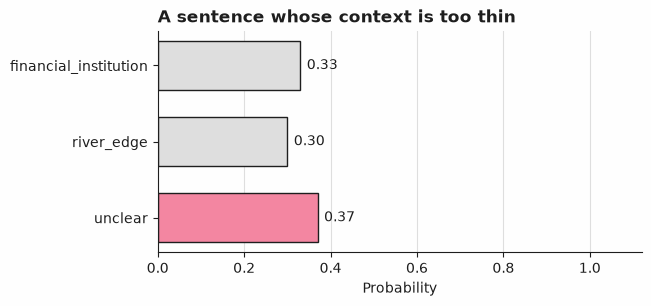

In [4]:
thin_example = demo["d01-bank-thin"]
thin_answer = decide(thin_example)
print(thin_example.fields["sentence"])
show_answer(thin_answer)
plot_answer_probabilities(thin_answer, title="A sentence whose context is too thin")

"Everyone was talking about the bank this week." could be the financial institution or the river bank, and the sentence gives nothing to decide between them: no mention of money or water, no activity near either one. The stored answer puts `unclear` on top at 0.37, just ahead of `financial_institution` (0.33) and `river_edge` (0.30), so `confidence` is only 0.06: `(0.37 - 1/3) / (1 - 1/3)`. That is the shape the use case calls for: when context is genuinely too thin, the probabilities spread close to even across all three options rather than one sense winning by a wide margin, and the rule below (not yet shown) sends an answer like this to review for choosing `unclear`, whatever its confidence.


In [5]:
clear_example = demo["d02-crane-machine"]
clear_answer = decide(clear_example)
print(clear_example.fields["sentence"])
show_answer(clear_answer)

The crane lifted the steel beam onto the fifth floor without a sound.
Choice: machine (confidence 0.88)
  machine  0.92  ##################
  bird     0.04  #
  unclear  0.04  #
Provenance: synthetic


"The crane lifted the steel beam onto the fifth floor without a sound." names the construction scene outright: a beam, a floor, lifting. The stored answer puts `machine` on top at 0.92, so `confidence` is 0.88, close to the ceiling of 1. Contrast this with the thin sentence above: both are a `Choice` over the same three options, and the gap between 0.06 and 0.88 is entirely the gap between a sentence that decides the sense and one that does not.


The bat glided silently between the trees, swooping low to snatch an insect before vanishing into the dark.
Choice: equipment (confidence 0.77)
  equipment  0.85  #################
  animal     0.10  ##
  unclear    0.05  #
Provenance: synthetic


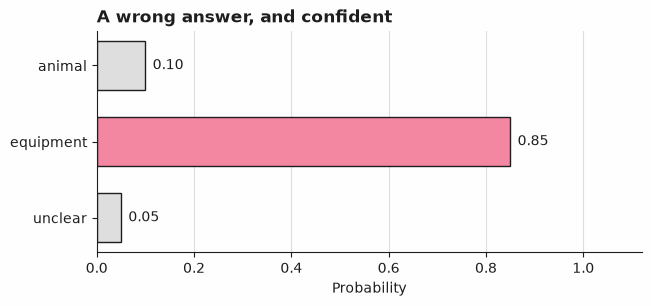

In [6]:
wrong_example = demo["d04-bat-wrong"]
wrong_answer = decide(wrong_example)
print(wrong_example.fields["sentence"])
show_answer(wrong_answer)
plot_answer_probabilities(wrong_answer, title="A wrong answer, and confident")

"The bat glided silently between the trees, swooping low to snatch an insect before vanishing into the dark." reads, to most people, like the animal: gliding, swooping, snatching an insect. The stored answer calls it `equipment` at confidence 0.77 anyway. This is a `demo` example, so nothing here is scored; it exists to show, before any aggregate number, that a wrong answer can still be a confident one — the same shape `t05-crane-wrong` has in `test`, discussed again below once the evaluation has reported on it. Nothing here says *why* a real model would get a sentence like this wrong, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.


## Python's part

Jev supplies the sense; what happens with it is code. `resolve` in `helpers.py` accepts the chosen sense as given only when it names one of the word's real senses *and* the answer's `confidence` is at or above a threshold. Two things send it to review regardless of confidence: choosing `unclear` (a model that says "I can't tell" should never be overridden into picking a side because it happened to sound sure of `unclear` itself), and choosing anything else that is not one of the word's own senses — defensive, since the criteria `build_questions` asks with never offer such an option, but the rule does not trust that silently. `tests/test_helpers.py` checks all three branches for every word and every one of its senses, so a rule that quietly exempted one word, one sense, or one of the two unconditional-review cases from a check would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose accepted subset of the 19 `validation` sentences that name a real sense is perfectly accurate — as much coverage as this fixture set allows without accepting a wrong answer *on validation*. (`validation` happens to contain no `unclear` answer at all — every one of its 19 stored answers names a real sense — so the branch that rejects `unclear` regardless of confidence is exercised only on `test` and in the unit tests above, not here.) Applying that frozen threshold to the three answers shown above, plus a fourth for contrast (a sentence the rule sends to review for low confidence even though it names a real sense and happens to be right), shows every outcome the rule can produce.


In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
# Only an answer naming a real sense of its own word could ever be accepted; "unclear" and any
# other option never can be, whatever the confidence, so both are left out of the pool the
# threshold is chosen from (empirically, every validation answer names a real sense, so this
# filter removes nothing here -- see the markdown above).
named = [
    (a.choice == g, a.confidence)
    for e, a, g in zip(val_examples, val_answers, val_gold, strict=True)
    if a.choice in helpers.SENSE_INVENTORY[e.fields["word"]]
]
threshold = select_confidence_threshold(
    [ok for ok, _ in named], [c for _, c in named], target_accuracy=1.0
)
print(f"answers naming a real sense: {len(named)} of {len(val_answers)}{selection}")
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}")

low_example = demo["d03-spring-low"]
low_answer = decide(low_example)
for shown_example, shown_answer in (
    (thin_example, thin_answer),
    (clear_example, clear_answer),
    (wrong_example, wrong_answer),
    (low_example, low_answer),
):
    word = shown_example.fields["word"]
    result = helpers.resolve(shown_example.fields["sentence_id"], word, shown_answer, threshold)
    print(
        f"{result.sentence_id} ({word}): {shown_answer.choice} at confidence "
        f"{shown_answer.confidence:.2f} -> {result.outcome} ({result.reason})"
    )

answers naming a real sense: 19 of 19 (a selection step, not a reported result)
chosen threshold, frozen from here on: 0.6250 (a selection step, not a reported result)
S139 (bank): unclear at confidence 0.06 -> review (chose unclear)
S140 (crane): machine at confidence 0.88 -> accepted (confident)
S142 (bat): equipment at confidence 0.77 -> accepted (confident)
S141 (spring): season at confidence 0.10 -> review (confidence below the threshold)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.resolve` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports the accuracy of the raw choice, overall and per target word, and the coverage, accuracy and risk the frozen rule produces on `test`. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.


In [8]:
def report(chosen, decided, gold, threshold):
    """Apply resolve to every answer and tally what it actually did."""
    results = [
        helpers.resolve(e.fields["sentence_id"], e.fields["word"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    accepted = [
        (a, g)
        for r, a, g in zip(results, decided, gold, strict=True)
        if r.outcome == helpers.ACCEPTED
    ]
    right = sum(a.choice == g for a, g in accepted)
    reasons = {}
    for r in results:
        if r.outcome == helpers.REVIEW:
            reasons[r.reason] = reasons.get(r.reason, 0) + 1
    return results, len(accepted), right, reasons


val_results, n_accepted, n_right, val_reasons = report(
    val_examples, val_answers, val_gold, threshold
)
print(f"validation, {len(val_examples)} examples{selection}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(f"accepted by the rule at this threshold: {n_accepted} of {len(val_examples)}{selection}")
print(f"right among those accepted: {n_right} of {n_accepted}{selection}")

validation, 19 examples (a selection step, not a reported result)
accuracy of the choice: 0.7895 (a selection step, not a reported result)
accepted by the rule at this threshold: 15 of 19 (a selection step, not a reported result)
right among those accepted: 15 of 15 (a selection step, not a reported result)


In [9]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, n_accepted_t, n_right_t, test_reasons = report(
    test_examples, test_answers, test_gold, threshold
)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(f"accepted by the rule: {n_accepted_t} of {len(test_examples)}{check}")
print(f"right among those accepted: {n_right_t} of {n_accepted_t}{check}")
print(f"sent to review: {sum(test_reasons.values())} of {len(test_examples)}{check}")
for reason, count in sorted(test_reasons.items()):
    print(f"  review because {reason}: {count}{check}")

test, 19 examples, threshold 0.6250 frozen (a pipeline check, not a Jev result)
accuracy of the choice: 0.8947 (a pipeline check, not a Jev result)
accepted by the rule: 15 of 19 (a pipeline check, not a Jev result)
right among those accepted: 14 of 15 (a pipeline check, not a Jev result)
sent to review: 4 of 19 (a pipeline check, not a Jev result)
  review because chose unclear: 1 (a pipeline check, not a Jev result)
  review because confidence below the threshold: 3 (a pipeline check, not a Jev result)


In [10]:
print(f"accuracy of the choice, per target word, test{check}")
for word in sorted(helpers.SENSE_INVENTORY):
    word_gold = [
        g for e, g in zip(test_examples, test_gold, strict=True) if e.fields["word"] == word
    ]
    word_answers = [
        a for e, a in zip(test_examples, test_answers, strict=True) if e.fields["word"] == word
    ]
    print(f"  {word:8s} {accuracy(word_gold, word_answers):.4f}  (n={len(word_gold)}){check}")

accuracy of the choice, per target word, test (a pipeline check, not a Jev result)
  bank     1.0000  (n=5) (a pipeline check, not a Jev result)
  bat      1.0000  (n=4) (a pipeline check, not a Jev result)
  crane    0.6000  (n=5) (a pipeline check, not a Jev result)
  spring   1.0000  (n=5) (a pipeline check, not a Jev result)


`crane` is the one word the choice gets wrong on `test`: two of its five sentences, `t05-crane-wrong` (`machine`, confident and wrong) and `t04-crane-thin` (answered `unclear`), giving `crane` 0.6000 where the other three words are all 1.0000. `accuracy` compares the raw choice against the gold label, so it treats `t04-crane-thin`'s `unclear` as a miss by construction: `unclear` is never a gold label, so an honest "I can't tell" counts exactly the same as a confident wrong answer in this figure, even though `resolve` sends both of `crane`'s errors to review or acceptance very differently (below). That pattern cannot be read as a finding about Jev: every probability above was written by hand for this fixture set, which was not designed to test whether `crane` is harder than `bank`, `spring` or `bat`. It is worth showing anyway, because this is exactly what a per-word breakdown is for: the overall accuracy of 0.8947 could hide that every miss landed on one word, which the numbers above do not.


The `accepted`/`review` counts above come straight from `resolve`; `evaluate_selective` reports the same split through `jev_cookbook.evaluation`'s own vocabulary, made exactly the same rather than merely agreeing with it by chance: `evaluate_selective` decides "answered" by comparing a confidence against the threshold on its own, with no notion of `unclear` or of a sense outside the word, so it is handed `0.0` (below any positive threshold) for every answer `resolve` rejects unconditionally, and each answer's real confidence otherwise — its own comparison against the threshold then lands exactly where `resolve` already put it. `coverage` is the fraction of all nineteen `test` sentences that clear the threshold and get a reported sense; among those, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction that are wrong despite having cleared the bar.


In [11]:
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
# resolve() rejects "chose unclear" and "not a sense of this word" regardless of confidence;
# 0.0 is below any positive threshold, so handing evaluate_selective that value for those two
# reasons (and the real confidence otherwise) makes its own confidence-vs-threshold split land
# on exactly what resolve already decided, rather than silently re-deriving a different one.
test_confidence_for_rule = [
    0.0
    if r.outcome == helpers.REVIEW and r.reason != "confidence below the threshold"
    else a.confidence
    for r, a in zip(test_results, test_answers, strict=True)
]
selective = evaluate_selective(test_correct, test_confidence_for_rule, threshold)
print(
    f"answered: {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

answered: 15 of 19 (coverage 0.7895) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9333 (a pipeline check, not a Jev result)
risk among those answered: 0.0667 (a pipeline check, not a Jev result)


Four of `test`'s nineteen sentences go to review instead of being reported as a result: `t03-bank-low`, `t04-spring-low` and `t04-bat-low` each name the right sense but too unconfidently to clear 0.6250, and `t04-crane-thin` answers `unclear` and so could never clear it regardless of confidence. Three of those four would have been right had the rule reported them anyway, so most of what review catches here was not actually a mistake; the fourth, `t04-crane-thin`, is one of `test`'s two wrong raw choices, caught for choosing `unclear` rather than for its confidence. The second wrong choice, `t05-crane-wrong`, is not among the four reviewed: its stored answer is wrong at confidence 0.70, comfortably above the threshold frozen on `validation`, so the rule accepts it anyway. That is why `risk` above is 0.0667 and not 0: a threshold chosen to be perfectly accurate on the sentences that named a real sense on `validation` is a guarantee about `validation`, not about `test` or about any sentence this recipe has not seen. This recipe does not teach a threshold as a guarantee it is not.


## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored sentences (plus 4 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, some of them wrong on purpose (including one wrong *and* confident, to show what a frozen threshold does not catch), so every number above describes this fixture set and not a model.


In [12]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard sentence to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `resolve` sends it.
- Add a fifth target word to `SENSE_INVENTORY` in `helpers.py`, with its own two senses, and a few sentences for it in `build_fixtures.py`; `senses_for` and `build_questions` need no change.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/), [`05-document-classification`](../05-document-classification/) and [`08-faq-selection`](../08-faq-selection/), which build a `Choice` over a fixed option set like this one.
